# No Lag Models

## This script accomplishes the following:

In this script, we will run the same models as in the previous script, but exclude the most predictive features, which we were given as a result. These are "conflict in the previous month" and "conflict in the previous year".

## Find the following steps below:

1. **Random Forest Model**

- Define features and label (number of conflicts, for each ZIP in PA, for each month)
- Perform 4-fold time-series-cross-validation
- Split the data, using January - September for Train and October - December for Test
- Normalize the sets
- Define the rf regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

2. **XGBoost Model**

- Define the xgb regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from joblib import dump, load
import joblib
from sklearn.compose import ColumnTransformer

In [2]:
#Dynamic search path configuration
import sys
import os

#Adjusting search path based on notebook's depth in directory --> iterates through directories until it finds directory name: US_conflict_forecasting
current_dir = os.getcwd()
while 'US_conflict_forecasting' not in os.path.basename(current_dir):
    current_dir = os.path.dirname(current_dir)

#Adjusting search path based on 'new' current directory
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from project_setup import setup_project
project_root_dir = setup_project()

Current Project Root Directory set to: /Users/danie/Desktop/Hertie/2. Semester/1. ML/0. Final Project/US_conflict_forecasting
Current Search Path set to: ['c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting', 'c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting\\3_Models', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32\\lib', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\Pythonwin', 'c:\\Users\\danie\\AppData\

### Load the data

In [3]:
# Load the data

data = pd.read_csv(os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset/Final_Dataset_noLag_clean.csv'))


## 1. Random Forest

### Features and labels, cross-validation, split and normalization

In [4]:
train = data[data['month'] <= 9]

test = data[data['month'] > 9]

In [5]:

X_train = train.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_train = train['event_count']


X_test = test.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_test = test['event_count']


In [6]:
# Time Series Cross Validation, 4 folds.

tscv = TimeSeriesSplit(n_splits = 4)

In [7]:
# Scaling Process for the Train set

# Extract relative and absolute columns

relative_feature_ranges = [(28, 33), (35, 62), (64, 68), (70, 88), (90, 110), (115, 115), (118, 120)]
absolute_feature_ranges = [(0, 27), (34, 34), (63, 63), (69, 69), (89, 89), (111, 114), (116, 117), (121, 153)]

# Helper function to extract column names based on index ranges
def get_columns_by_index_ranges(data, ranges):
    columns = []
    for start, end in ranges:
        columns.extend(data.columns[start:end+1])
    return columns

# Extract columns
relative_columns_train = get_columns_by_index_ranges(X_train, relative_feature_ranges)
absolute_columns_train = get_columns_by_index_ranges(X_train, absolute_feature_ranges)

# Apply different scalers
preprocessor = ColumnTransformer(
    transformers=[
        ('abs', StandardScaler(), absolute_columns_train),
        ('rel', MinMaxScaler(), relative_columns_train)
    ])

In [8]:
# Scaling Process for the Test set

# Extract relative and absolute columns

relative_feature_ranges = [(28, 33), (35, 62), (64, 68), (70, 88), (90, 110), (115, 115), (118, 120)]
absolute_feature_ranges = [(0, 27), (34, 34), (63, 63), (69, 69), (89, 89), (111, 114), (116, 117), (121, 153)]

# Helper function to extract column names based on index ranges
def get_columns_by_index_ranges(data, ranges):
    columns = []
    for start, end in ranges:
        columns.extend(data.columns[start:end+1])
    return columns

# Extract columns
relative_columns_test = get_columns_by_index_ranges(X_test, relative_feature_ranges)
absolute_columns_test = get_columns_by_index_ranges(X_test, absolute_feature_ranges)

# ColumnTransformer to apply different scalers to different sets of features
preprocessor = ColumnTransformer(
    transformers=[
        ('abs', StandardScaler(), absolute_columns_test),
        ('rel', MinMaxScaler(), relative_columns_test)
    ])

In [9]:
# Apply the preporcessor to the data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

### Define the regressor and run the model

In [10]:
rf_regressor = RandomForestRegressor(n_estimators = 100, random_state = 100)

In [11]:
rf_regressor.fit(X_train_scaled, Y_train)

RandomForestRegressor(random_state=100)

### Feature importance

In [12]:
# Which are the most important features?

feature_importances = rf_regressor.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

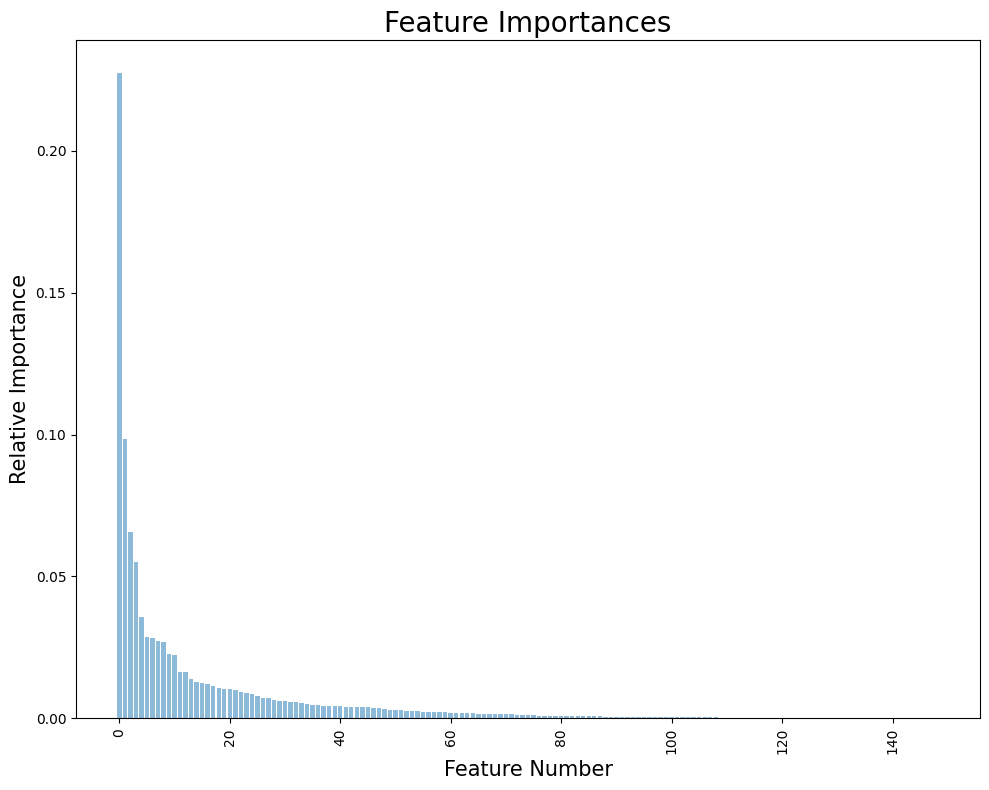

In [13]:
feature_importances = rf_regressor.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

# Plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center', alpha=0.5)

num_features = len(feature_importances)
ticks = range(0, num_features, 20)
tick_labels = [str(i) for i in ticks]

plt.xticks(ticks, tick_labels, rotation=90)
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature Number', fontsize=15)
plt.tight_layout() 
plt.show()


### Extract most important feature names

In [14]:
# Extract the feature names

feature_names = X_train.columns

for i in range(20):
    print(f'{feature_names[sorted_indices[i]]}: {feature_importances[sorted_indices[i]]}')

act_wor: 0.22758318963966384
fatalities: 0.0985004056681839
gun-violence: 0.06580176615274548
set_peaceful_prot: 0.05510936485823085
environment: 0.035585426067276535
Two or more races, 2022: 0.0288056222439894
Median Family Income, 2022: 0.02824316099976049
act_gov: 0.02743371017876346
act_rel: 0.026908075057588254
act_nat: 0.022730297111851087
Household Income $100,000 to $199,999: 0.02224915571204955
50%+ of Income for Rent, 2022: 0.01626911277533639
topic1: 0.016171675435546352
White, Not Hispanic or Latino, 2022: 0.013748217101003251
topic0: 0.012748223473943311
months_since_election: 0.012624819580169724
# Working Age Adults (18-64) With Disability, 2022: 0.011964481332584972
set_mob: 0.011238899979344004
Foreign Born, 2022: 0.010748096648846859
Employed in Construction, 2022: 0.01038689373522909


### Run Grid Search to find the best parameters

In [15]:
# Grid Search for best parameters

# Adjust number of trees in forest, max depth of trees, and minimum samples per leaf

# n_estimators: Number of trees in the forest, to take into account for the prediction
# max_depth: Maximum depth of the tree. From root to leaf, basically controls complexity of the tree and can lead/prevent overfitting. The more splits, the more complex the tree and the more likely to fit noise.
# min_samples_split: Minimum number of samples required to split an internal node


# Prevents overfitting and improves the generalization of the model

param_grid_rf = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 7]
}

In [16]:
cv_rf = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf, cv = tscv, n_jobs=-1)
cv_rf.fit(X_train_scaled, Y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None),
             estimator=RandomForestRegressor(random_state=100), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 40],
                         'min_samples_split': [2, 5, 7],
                         'n_estimators': [100, 200, 400]})

### Re-run feature importance analysis

In [17]:
importances_gs = cv_rf.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances_gs
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                                              feature  importance
6                                             act_wor    0.228500
0                                          fatalities    0.095050
18                                       gun-violence    0.094326
10                                  set_peaceful_prot    0.054117
17                                        environment    0.028114
..                                                ...         ...
21                      Rural_Urban_Commerical Status    0.000003
55  Children (<19 Years Old) with No Health Insura...    0.000003
14                                   set_violent_prot    0.000000
63  Single Parents (No Spouse) with Children (<18)...    0.000000
50               Total # People with Disability, 2022    0.000000

[149 rows x 2 columns]


### Plot again

In [18]:
feature_importance_df['feature_num'] = range(1, len(feature_importance_df) + 1)

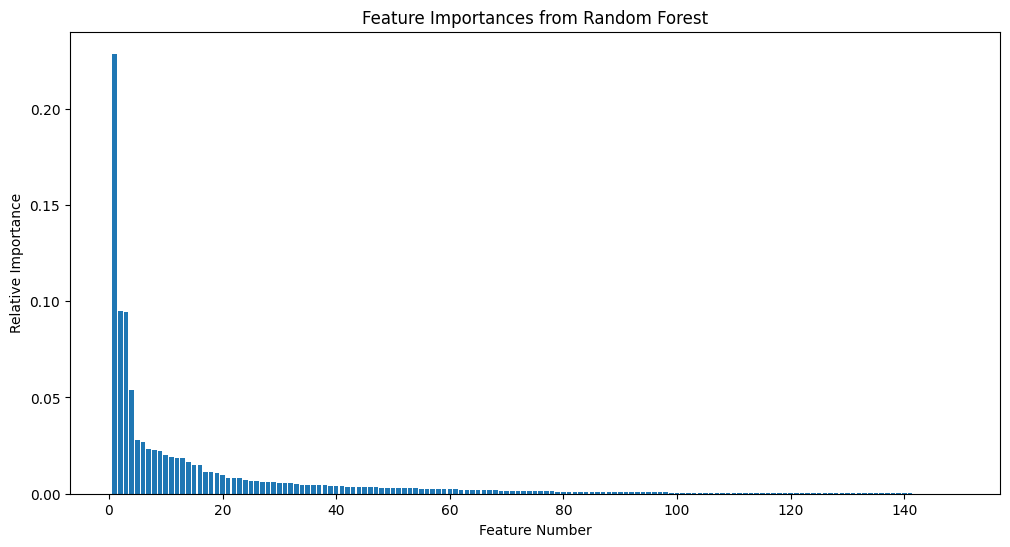

In [19]:
plt.figure(figsize=(12, 6))
plt.bar(feature_importance_df['feature_num'], feature_importance_df['importance'])
plt.xlabel('Feature Number')
plt.ylabel('Relative Importance')
plt.title('Feature Importances from Random Forest')
plt.show()

### Feature importance stll very similar after runnin with best parameters

## Run the predictions

### Without Best Parameters

In [20]:
Y_pred_rf = rf_regressor.predict(X_test_scaled)

predictions_rf = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_rf})
print(Y_pred_rf)

[0. 0. 0. ... 0. 0. 0.]


In [21]:
mse_rf = mean_squared_error(Y_test, Y_pred_rf)

print('Mean Squared Error:', mse_rf)

Mean Squared Error: 0.13348839789052558


### Including the Best Parameters

In [22]:
Y_pred_gs = cv_rf.predict(X_test_scaled)

predictions_gs = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_gs})
print(Y_pred_gs)

[0. 0. 0. ... 0. 0. 0.]


In [23]:
mse_gs = mean_squared_error(Y_test, Y_pred_gs)

print('Mean Squared Error:', mse_gs)

Mean Squared Error: 0.12932949854519005


## Save predictions

In [24]:
# Get ZIP code and month for each prediction
ZIP_results_rf = pd.merge(predictions_rf, data[['ZCTA', 'month']], left_index=True, right_index=True)

# Include all instances in which the model predicted a positive number of events
ZIP_results_rf = ZIP_results_rf[ZIP_results_rf['Predicted'] > 0]


# XGBoost Model


### Initialize and fit the XGBoost Regressor

In [25]:
xgb = XGBRegressor(use_label_encoder = False, eval_metric = 'logloss', random_state = 1 )
xgb.fit(X_train_scaled, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='logloss',
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, random_state=1, ...)

### Run Grid Search to find the best parameters:

In [26]:
param_grid_1 = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

In [27]:
# Progress function
def progress_printout(n_completed, n_tasks, *args, **kwargs):
    if n_completed % 10 == 0:
        print(f"{n_completed}/{n_tasks} fits completed")

In [28]:
# Set up a custom progress printout for joblib
with joblib.parallel.parallel_backend('threading', n_jobs=-1):
    joblib.parallel.parallel_printout = progress_printout

# Initialize XGB and GridSearch
# Include n_jobs = -1 to use all available cores
grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid_1, scoring='neg_mean_squared_error', cv = tscv, verbose=1, n_jobs = -1)
grid_search.fit(X_train_scaled, Y_train)

# Print the best parameters
best_params = grid_search.best_params_
print("Best parameters:", best_params)

Fitting 4 folds for each of 1440 candidates, totalling 5760 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 50, 'subsample': 0.6}


### Re-run the model with optimal parameter values

In [29]:
# Re-train the model with the best parameters found above
xgb_optimized = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state = 1)
xgb_optimized.fit(X_train_scaled, Y_train)

# Make predictions
y_pred_optimized = xgb_optimized.predict(X_test_scaled)

### Run feature importance analysis

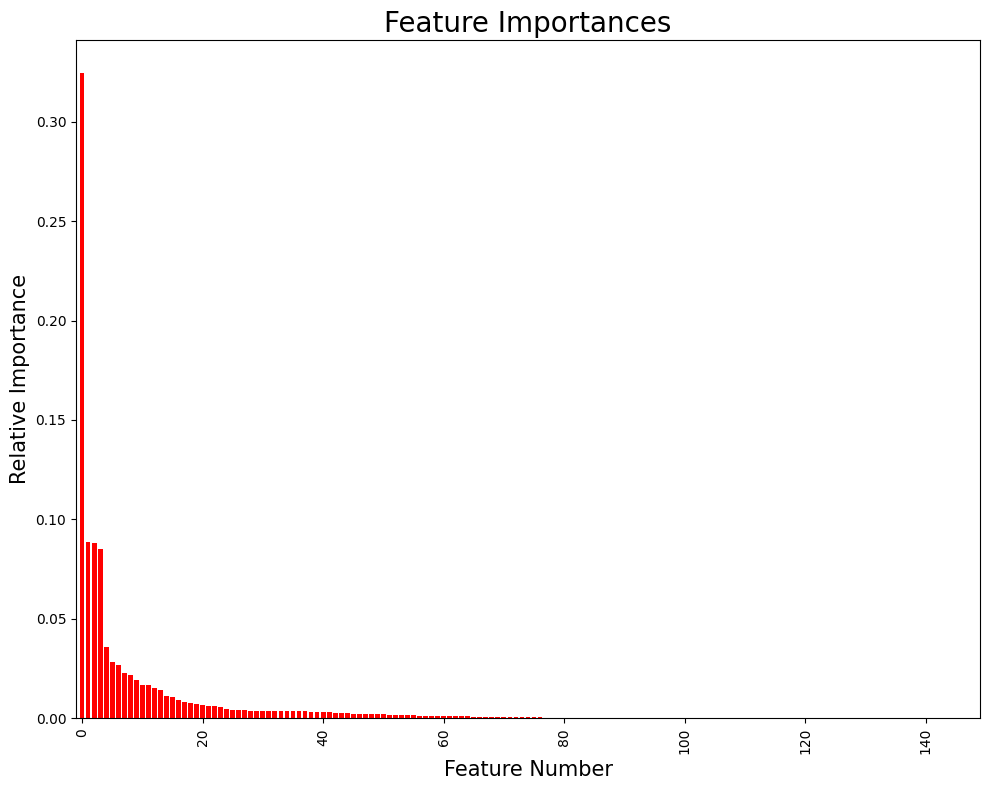

In [30]:
importances_xgb = xgb_optimized.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

# Create the plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(X_train.shape[1]), importances_xgb[indices_xgb], color='r', align='center')

# Show ticks from 0 and then every 20th feature
num_features = X_train.shape[1]
ticks = range(0, num_features, 20)
tick_labels = [str(i) for i in ticks]

plt.xticks(ticks, tick_labels, rotation=90)
plt.xlim([-1, num_features])
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature Number', fontsize=15)
plt.tight_layout()  # Adjusts the plot to ensure everything fits without overlapping
plt.show()


In [31]:
# Print the 10 most important features for the XGB model

for i in range(20):
    print(f'{X_train.columns[indices_xgb[i]]}: {importances_xgb[indices_xgb[i]]}')

# Children (<18) With Disability, 2022: 0.3246358036994934
Median Family Income, 2022: 0.0885549932718277
18 to 34 Years Old, 2022: 0.08828206360340118
topic0: 0.0850115567445755
gun-violence: 0.03599635884165764
Household Income $100,000 to $199,999: 0.02840285561978817
fatalities: 0.02686137892305851
act_wor: 0.022861771285533905
act_gov: 0.021927453577518463
Two or more races, 2022: 0.01905817538499832
Some College, No Degree, 2022: 0.016921566799283028
% Households with Income from Retirement Sources, 200: 0.01676453836262226
White, Not Hispanic or Latino, 2022: 0.015285991132259369
set_peaceful_prot: 0.01439538411796093
topic8: 0.011482595466077328
Bachelor's Degree or Higher, 2022: 0.01070086844265461
Median age : 0.008993611671030521
environment: 0.00829983502626419
Total Population, 2022: 0.007652215659618378
unions: 0.007449469994753599


## Make the Predictions with the XGBoost Model

In [32]:
predictions_xgb = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_optimized})

In [33]:
ZIP_results_xgb = pd.merge(predictions_xgb, data[['ZCTA', 'month']], left_index=True, right_index=True)

In [34]:
ZIP_results_xgb = ZIP_results_xgb[ZIP_results_xgb['Predicted'] > 0]

In [35]:
# Calculate MSE for XGBoost
mse_xgb = mean_squared_error(Y_test, y_pred_optimized)

print('Mean Squared Error:', mse_xgb)

Mean Squared Error: 0.13895750710430155


### Quick Linear Model as benchmark

In [36]:
# Calculate a linear model on the dataset

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)

Y_pred_lr = lr.predict(X_test_scaled)

# MSE of linear regression model
mse_lr = mean_squared_error(Y_test, Y_pred_lr)

print('Mean Squared Error:', mse_lr)

Mean Squared Error: 1.0773801527193978e+23


# Evaluation and Comparison of No-Lag models

In [37]:
# Print MSE of both models

print('Mean Squared Error Random Forest:', mse_gs)
print('Mean Squared Error XGBoost:', mse_xgb)
print('Mean Squared Error Linear Regression:', mse_lr)

Mean Squared Error Random Forest: 0.12932949854519005
Mean Squared Error XGBoost: 0.13895750710430155
Mean Squared Error Linear Regression: 1.0773801527193978e+23


In [38]:
# Compare MSE of the models in a table

mse_comparison = pd.DataFrame({'Model': ['Random Forest', 'XGBoost', 'Linear Model'], 'MSE': [mse_gs, mse_xgb, mse_lr]})
print(mse_comparison)

           Model           MSE
0  Random Forest  1.293295e-01
1        XGBoost  1.389575e-01
2   Linear Model  1.077380e+23


In [39]:
# Compare the Root Mean Squared Error of the models

rmse_rf = np.sqrt(mse_gs)
rmse_xgb = np.sqrt(mse_xgb)
rmse_lr = np.sqrt(mse_lr)

rmse_comparison = pd.DataFrame({'Model': ['Random Forest', 'XGBoost', 'Linear Model'], 'RMSE': [rmse_rf, rmse_xgb, rmse_lr]})
print(rmse_comparison)

           Model          RMSE
0  Random Forest  3.596241e-01
1        XGBoost  3.727700e-01
2   Linear Model  3.282347e+11


In [40]:
# MSE and RMSE in one table

mse_rmse_comparison = pd.merge(mse_comparison, rmse_comparison, on='Model')
print(mse_rmse_comparison)

           Model           MSE          RMSE
0  Random Forest  1.293295e-01  3.596241e-01
1        XGBoost  1.389575e-01  3.727700e-01
2   Linear Model  1.077380e+23  3.282347e+11


In [41]:

# Show both models' predictions for ZIP codes with at least one conflict event in one table, so we can compare them side by side for each ZIP code

ZIP_results_comparison = pd.merge(ZIP_results_rf, ZIP_results_xgb, on=['ZCTA', 'month'], suffixes=('_rf', '_xgb'))
print(ZIP_results_comparison)

# Calculate the difference between the predicted values

ZIP_results_comparison['Difference'] = ZIP_results_comparison['Predicted_rf'] - ZIP_results_comparison['Predicted_xgb']

    Actual_rf  Predicted_rf     ZCTA  month  Actual_xgb  Predicted_xgb
0         1.0          2.12  15026.0   10.0         1.0       1.053017
1         1.0          1.94  15026.0   12.0         1.0       0.501888
2         1.0          1.69  15068.0   12.0         1.0       1.359979
3         1.0          2.13  15101.0   11.0         1.0       0.594254
4         1.0          1.05  15132.0   10.0         1.0       1.134755
5         1.0          1.15  15144.0   11.0         1.0       0.660474
6        21.0          7.20  15219.0   10.0        21.0       9.119193
7        20.0          4.71  15219.0   11.0        20.0       4.782057
8        16.0          5.53  15219.0   12.0        16.0       3.501444
9         1.0          1.46  15228.0   10.0         1.0       1.494952
10        1.0          1.06  15401.0   10.0         1.0       0.448016
11        1.0          1.32  16214.0   10.0         1.0       1.257905
12        2.0          2.04  16501.0   10.0         2.0       3.403867
13    